In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import akshare as ak
from tqdm import tqdm
from datetime import datetime, timedelta
from collections import Counter

In [2]:
df = ak.stock_zh_a_hist(
    symbol="601899",      
    period="daily",
    start_date="20260201",
    end_date="20260210",
    adjust="qfq"          # 前复权（做中长线建议用）
)

print(df.head()) 

           日期    股票代码     开盘     收盘     最高     最低      成交量           成交额  \
0  2026-02-02  601899  36.87  36.61  38.73  36.27  7140436  2.668618e+10   
1  2026-02-03  601899  37.84  38.81  38.95  37.08  4766103  1.807406e+10   
2  2026-02-04  601899  39.50  39.16  39.99  38.68  3267366  1.284468e+10   
3  2026-02-05  601899  38.13  37.45  38.50  36.57  3583731  1.340707e+10   
4  2026-02-06  601899  35.55  37.19  37.82  35.50  3277748  1.210700e+10   

     振幅   涨跌幅   涨跌额   换手率  
0  6.13 -8.79 -3.53  3.47  
1  5.11  6.01  2.20  2.31  
2  3.38  0.90  0.35  1.59  
3  4.93 -4.37 -1.71  1.74  
4  6.19 -0.69 -0.26  1.59  


In [15]:
stock_list = ak.stock_info_a_code_name()

#测试版
stock_list = stock_list.head(300)

In [7]:
code = "000001"
end_date = datetime.today()
start_date = end_date - timedelta(days=3*365)

df = ak.stock_zh_a_hist(
    symbol=code,
    period="daily",
    adjust="qfq",
    start_date=start_date.strftime("%Y%m%d"),
    end_date=end_date.strftime("%Y%m%d"),
)

df['MA20'] = df['收盘'].rolling(20).mean()
df['MA60'] = df['收盘'].rolling(60).mean()
df

,日期,股票代码,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率,MA20,MA60
0,2023-02-15,000001,12.10,11.82,12.11,11.77,1250244,1.713567e+09,2.81,-2.39,-0.29,0.64,NaN,NaN
1,2023-02-16,000001,11.83,11.75,12.06,11.65,1279123,1.757431e+09,3.47,-0.59,-0.07,0.66,NaN,NaN
2,2023-02-17,000001,11.78,11.58,11.87,11.58,918364,1.246777e+09,2.47,-1.45,-0.17,0.47,NaN,NaN
3,2023-02-20,000001,11.65,12.30,12.30,11.64,2116191,2.945970e+09,5.70,6.22,0.72,1.09,NaN,NaN
4,2023-02-21,000001,12.21,12.25,12.35,12.07,990495,1.393153e+09,2.28,-0.41,-0.05,0.51,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,2026-02-09,000001,11.05,11.07,11.11,11.01,619717,6.852182e+08,0.90,0.18,0.02,0.32,11.0575,11.400333
727,2026-02-10,000001,11.07,11.06,11.10,11.02,600430,6.641402e+08,0.72,-0.09,-0.01,0.31,11.0370,11.388833
728,2026-02-11,000001,11.06,11.07,11.09,11.02,431041,4.768019e+08,0.63,0.09,0.01,0.22,11.0225,11.378833
729,2026-02-12,000001,11.07,10.96,11.08,10.93,681340,7.483385e+08,1.36,-0.99,-0.11,0.35,11.0050,11.368333


In [7]:
df = ak.stock_yjbb_em(date="20250930")  # 年报
df

  0%|          | 0/12 [00:00<?, ?it/s]

,序号,股票代码,股票简称,每股收益,营业总收入-营业总收入,营业总收入-同比增长,营业总收入-季度环比增长,净利润-净利润,净利润-同比增长,净利润-季度环比增长,每股净资产,净资产收益率,每股经营现金流量,销售毛利率,所处行业,最新公告日期
0,1,301152,天力锂能,-0.7300,1.534972e+09,11.178524,3.7677,-8.721018e+07,48.91,-43.5113,11.049036,-6.43,0.433494,4.726035,电池,2026-02-13
1,2,603213,镇洋发展,0.1200,1.972784e+09,-1.959755,-15.0972,5.067504e+07,-66.07,-99.7199,4.203592,2.66,0.496714,9.740548,化学原料,2026-01-31
2,3,002829,星网宇达,0.1800,2.664306e+08,14.965255,96.2154,3.837488e+07,260.00,1406.2962,8.270176,2.26,-0.551331,19.483330,航天装备Ⅱ,2026-01-31
3,4,002726,龙大美食,-0.1700,7.625148e+09,-4.853270,9.2566,-1.790737e+08,-349.93,-776.0280,1.000946,-15.40,-0.011943,3.052267,食品加工,2026-01-31
4,5,000736,*ST中地,-2.2200,1.429311e+10,16.477344,-29.0291,-1.660324e+09,-11.50,30.0356,1.669932,-37.66,-0.129678,-0.268162,房地产开发,2026-01-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5826,5827,002837,英维克,0.4100,4.026031e+09,40.194697,-11.4390,3.990697e+08,13.13,9.4251,3.392592,12.97,-0.326694,27.319892,专用设备,2025-10-14
5827,5828,920357,雅葆轩,0.6100,4.189105e+08,55.902109,10.3772,4.871875e+07,36.59,13.0543,4.822441,12.19,-0.587188,19.934915,消费电子,2025-10-13
5828,5829,833183,超凡股份,0.7200,4.305612e+08,8.911268,NaN,4.178035e+07,25.03,NaN,3.827876,18.45,0.940205,35.204453,None,2025-10-13
5829,5830,300409,道氏技术,0.5629,6.000862e+09,-1.790048,23.8076,4.154460e+08,182.45,-0.8548,10.266359,5.48,1.068604,21.252957,电池,2025-10-11


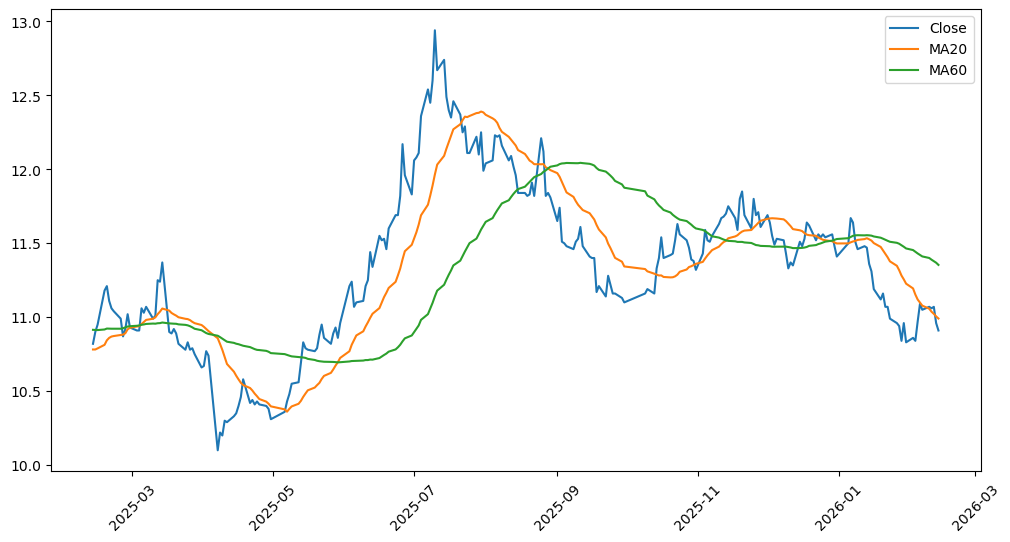

In [ ]:
df_1y = df.tail(250)

plt.figure(figsize=(12,6))
plt.plot(df_1y['日期'], df_1y['收盘'], label='Close')
plt.plot(df_1y['日期'], df_1y['MA20'], label='MA20')
plt.plot(df_1y['日期'], df_1y['MA60'], label='MA60')
plt.legend()
plt.xticks(rotation=45)
plt.show()




In [16]:
results = []

for _, row in tqdm(stock_list.iterrows(), total=len(stock_list)):
    code = row['code']
    try:
        df = ak.stock_zh_a_hist(symbol=code, period="daily", adjust="qfq")
        df['MA20'] = df['收盘'].rolling(20).mean()
        df['MA60'] = df['收盘'].rolling(60).mean()

        if df.shape[0] < 70:
            continue

        conds = midterm_entry_signal(df)
        if all(conds.values()):
            results.append({
                "code": code,
                "name": row['name'],
                **conds
            })
    except:
        continue

pd.DataFrame(results)


100%|██████████| 300/300 [06:04<00:00,  1.21s/it]


,code,name,trend_ok,pullback_ok,volume_contract,rebound
0,000423,东阿阿胶,True,True,True,True
1,000428,华天酒店,True,True,True,True
2,000738,航发控制,True,True,True,True


In [6]:
print(stock_list.head(100))

      code   name
0   000001   平安银行
1   000002  万  科Ａ
2   000004  *ST国华
3   000006   深振业Ａ
4   000007    全新好
..     ...    ...
95  000509   华塑控股
96  000510    新金路
97  000513   丽珠集团
98  000514  渝 开 发
99  000516   国际医学

[100 rows x 2 columns]


In [10]:
#中长线进场点；可随时修改纪律，扫描全市场的股票
def midterm_entry_signal(df):
    df = df.copy()
    
    # 计算均线
    df['MA20'] = df['收盘'].rolling(20).mean()
    df['MA60'] = df['收盘'].rolling(60).mean()
    
    latest = df.iloc[-1]
    prev = df.iloc[-2]
    
    # ===== 趋势条件 =====
    trend = (
        latest['收盘'] > latest['MA60'] and
        latest['MA20'] > latest['MA60'] and
        df['MA60'].iloc[-1] > df['MA60'].iloc[-5] and
        df['MA20'].iloc[-1] > df['MA20'].iloc[-5]
    )
    
    # ===== 回调条件 =====
    recent_low = df['最低'].iloc[-8:].min()
    pullback_ok = recent_low >= latest['MA20']
    
    # ===== 缩量 =====
    recent_vol = df['成交量'].iloc[-5:].mean()
    base_vol = df['成交量'].iloc[-20:].mean()
    volume_contract = recent_vol < base_vol
    
    # ===== 再启动 =====
    rebound = latest['收盘'] > prev['收盘']
    
    conds = {
        "trend_ok": trend,
        "pullback_ok": pullback_ok,
        "volume_contract": volume_contract,
        "rebound": rebound
    }
    
    return conds

In [15]:
results

[]

In [ ]:
#我的股票：在以下bracket添加目前有仓位的股票
my_stock = []




